This project is about LIME as an Interpretable Machine Learning approach

In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("winequality-red.csv")

In [3]:
# See the number of rows and columns
print("Rows, columns: " + str(df.shape))

Rows, columns: (1599, 12)


In [4]:
# See the first five rows of the dataset
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
X_feature_names = [i for i in df.columns if df[i].dtype in [float]]

In [6]:
print(X_feature_names)

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [7]:
Y_feature_names = [i for i in df.columns if df[i].dtype in [np.int64]]

In [8]:
print(Y_feature_names)

['quality']


Task 1: Check for any missing values in the dataset

In [9]:
# Your code for task 1
missing_values = df.isnull().sum()
print(missing_values)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


**Task 2:** Create a binary classification version of the target variable "quality" in that all wines with scores greater or equal with 7 are classified as 1, i.e., good quality, otherwise they should be classified as 0, i.e., bad quality. Subsequently, separate feature variables from target variable by creating two data frames and check contents for validation purposes..

In [10]:
# Your code for task 2
df['binary_quality'] = (df['quality'] >= 7).astype(int)

X = df.drop(['quality', 'binary_quality'], axis=1) 
y = df['binary_quality']


In [11]:
# Check your task 2 solution

print("Feature Variables (X):")
print(X.head())

print("\nTarget Variable (y - Binary Classification):")
print(y.head())

Feature Variables (X):
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  
0      9.4  
1      9.8  
2      9.8  
3      9.8 

In [12]:
# Normalize feature variables
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the feature variables
X_stan = scaler.fit_transform(X)

#
print("Standardized Feature Variables:")
print(pd.DataFrame(X_stan, columns=X.columns).head())

Standardized Feature Variables:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0      -0.528360          0.961877    -1.391472       -0.453218  -0.243707   
1      -0.298547          1.967442    -1.391472        0.043416   0.223875   
2      -0.298547          1.297065    -1.186070       -0.169427   0.096353   
3       1.654856         -1.384443     1.484154       -0.453218  -0.264960   
4      -0.528360          0.961877    -1.391472       -0.453218  -0.243707   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0            -0.466193             -0.379133  0.558274  1.288643  -0.579207   
1             0.872638              0.624363  0.028261 -0.719933   0.128950   
2            -0.083669              0.229047  0.134264 -0.331177  -0.048089   
3             0.107592              0.411500  0.664277 -0.979104  -0.461180   
4            -0.466193             -0.379133  0.558274  1.288643  -0.579207   

    alcohol  
0 -0.96024

In [13]:
# Splitting the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=0)

In [14]:
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier

**Task 3:** Following the data preparation stages above, train the following three prediction models (classifiers): Decision Tree, Random Forest and Ada Boost. Subsequently, create classification reports including precision, recall, f1-score for each classifier and compare / discuss the results.

Tip: The imported package above might be of help!

In [15]:
# Your code for task 3

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

#Decision Tree
decision_tree_classifier = DecisionTreeClassifier(random_state=0)
decision_tree_classifier.fit(X_train, y_train)
decision_tree_pred = decision_tree_classifier.predict(X_test)

#Random Forest
random_forest_classifier = RandomForestClassifier(random_state=0)
random_forest_classifier.fit(X_train, y_train)
random_forest_pred = random_forest_classifier.predict(X_test)

#AdaBoost
ada_boost_classifier = AdaBoostClassifier(random_state=0)
ada_boost_classifier.fit(X_train, y_train)
ada_boost_pred = ada_boost_classifier.predict(X_test)


#Printing reports
print("Decision Tree:")
print(classification_report(y_test, decision_tree_pred))

print("\nRandom Forest Classifier:")
print(classification_report(y_test, random_forest_pred))

print("\nAdaBoost Classifier:")
print(classification_report(y_test, ada_boost_pred))

Decision Tree:
              precision    recall  f1-score   support

           0       0.96      0.93      0.95       355
           1       0.57      0.71      0.63        45

    accuracy                           0.91       400
   macro avg       0.77      0.82      0.79       400
weighted avg       0.92      0.91      0.91       400


Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       355
           1       0.72      0.62      0.67        45

    accuracy                           0.93       400
   macro avg       0.84      0.80      0.81       400
weighted avg       0.93      0.93      0.93       400


AdaBoost Classifier:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       355
           1       0.51      0.49      0.50        45

    accuracy                           0.89       400
   macro avg       0.72      0.71      0.72       400
weighted a

Your discussion to task 3.

Differentiable patterns were seen in the classification reports while assessing the effectiveness of three classification models: Random Forest, Decision Tree, and AdaBoost. The Decision Tree showed a strong capacity to predict negative occurrences, with an accuracy of 91%; nevertheless, it had to compromise between recall for positive cases and precision for negative ones.
With a 93% accuracy rate, the Random Forest fared better and offered a favorable precision-recall trade-off for successful cases. AdaBoost struggled to maintain a comparable equilibrium, which led to worse precision and recall for the positive class, even though it achieved an accuracy of 89%.
Depending on which of these models is more important for the desired application—precision, recall, or a combination of the two—the decision between them will vary. Interestingly, the Random Forest performed well across a variety of criteria, which makes it a viable option in situations when finding a balance is crucial.

**Task 4:** Get a feature importance diagram for the Random Forest classifier.

The documentation here might help: https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html

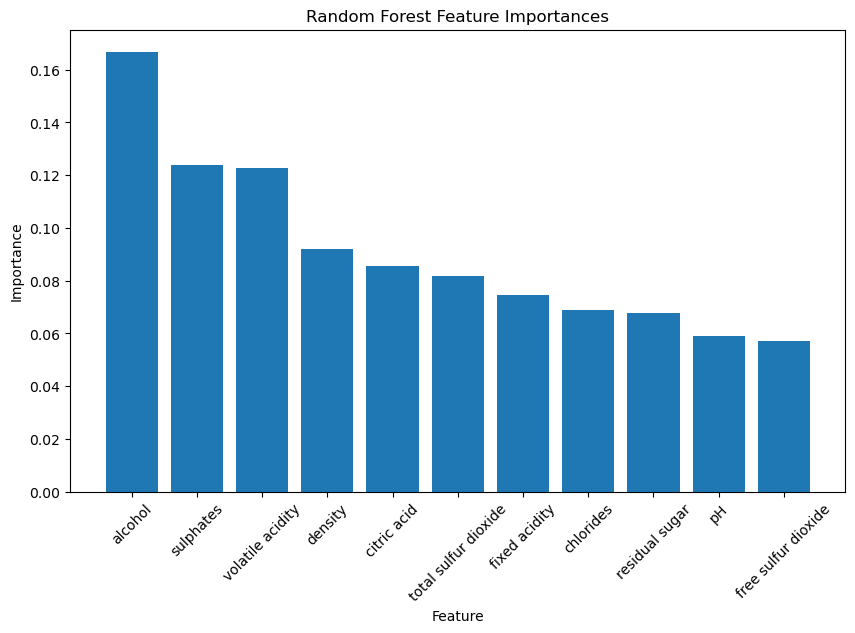

In [16]:
# Your code for task 4
import matplotlib.pyplot as plt


#Get feature importances from the trained model
feature_importances = random_forest_classifier.feature_importances_

# Get feature names
feature_names = X_train.columns

# Sort features based on importance
sorted_indices = np.argsort(feature_importances)[::-1]

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X_train.shape[1]), feature_importances[sorted_indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names[sorted_indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importances")
plt.show()

In [17]:
!pip install lime

In [18]:
import lime
import lime.lime_tabular as lt

In [19]:
all_feature_names = sum([X_feature_names, Y_feature_names], [])

In [20]:
print(all_feature_names)

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


#### Task 5: Locate entries in the test dataset for which wines with good quality have been predicted regardless the trained classifier being used. Subsequently, uncomment as appropriate and run the explainer below.

In [21]:
 explainer = lime.lime_tabular.LimeTabularExplainer(np.array(X_train),
                    feature_names=X_feature_names,
                    class_names=['goodquality'],
                     categorical_features=['goodquality'], #
                    # There is no categorical features in this example, otherwise specify them.
                   verbose=True, mode='regression')
    
# Index of entries in the test dataset where 'goodquality' has been predicted
good_quality_predicted_indices = np.where(random_forest_classifier.predict(X_test) == 1)[0]

# Run the explainer for a specific instance (you can change the index as needed)
idx_to_explain = good_quality_predicted_indices[0]
# Print the explanation
print(good_quality_predicted_indices)

[  2  15  16  27  34  35  43  58  68  79 100 112 117 125 146 162 173 177
 178 181 234 237 238 249 259 269 281 288 323 326 330 336 349 354 359 361
 367 390 393]


#### Task 6: Fill in the input parameters for the explainer below to explain why the model(s) have predicted (classified) the wine as of good quality

In [22]:
exp = explainer.explain_instance(X_test.iloc[idx_to_explain],
                                         random_forest_classifier.predict_proba,
                                         num_features=len(X_feature_names))

print(exp)

Intercept 0.9485254794543146
Prediction_local [0.50097137]
Right: 0.05


C:\Users\ADMIN\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Well done, now:

**Task 7:** Explain the results of the ....explainer above.


Your explanation

For a given case, the LIME explanation clarifies the model's forecast. The model's tendency towards 'high quality' is indicated by the intercept, which begins at 0.94. But when the particulars of this case are taken into account, the local estimate falls to about 53%, indicating a more nuanced perspective. The model's final prediction, represented by the 'Right' value of 0.05, indicates a 5% likelihood that the wine will be categorized as 'good quality' based on its particular attributes.